# E-Commerce Sales & Customer Analytics Using SQL and Power BI

## Project Overview

This project analyzes e-commerce sales, customer behavior, delivery performance, and product trends using the Olist E-Commerce Dataset.

The analysis focuses on:

- Sales performance
- Customer analytics
- Order trends
- Product category performance
- Delivery efficiency
- Customer satisfaction
- Business KPIs

The project combines:

- SQL for querying and data analysis
- Power BI for dashboarding and visualization
- Business analytics for actionable insights

## Dataset

Dataset Used:

Olist E-Commerce Dataset

Main tables:

Table	Description
- customers	Customer information
- orders	Order details and timestamps
- order_items	Products purchased
- products	Product metadata
- payments	Payment information
- reviews	Customer reviews
- sellers	Seller information

## Business Questions

This project answers the following business questions:

- What are the overall sales trends?
- Which product categories generate the most revenue?
- Which customers spend the most?
- What is the repeat customer rate?
- Which regions generate the highest sales?
- How efficient are deliveries?
- Which sellers receive the best customer ratings?
- What factors impact customer satisfaction?

## Database Schema
Recommended Relationships
customers.customer_id → orders.customer_id
orders.order_id → order_items.order_id
orders.order_id → payments.order_id
orders.order_id → reviews.order_id
order_items.product_id → products.product_id
order_items.seller_id → sellers.seller_id

## Jupyter Notebook Setup

### Import Libraries

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### Create SQLite Database Connection

In [64]:
conn = sqlite3.connect('olist.db')

### Load CSV Files

In [62]:
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')

### Import Data into SQLite

In [57]:
orders.to_sql(
    'olist_orders_dataset',
    conn,
    if_exists='replace',
    index=False
)
customers.to_sql(
    'olist_customers_dataset',
    conn,
    if_exists='replace',
    index=False
)
payments.to_sql(
    'olist_order_payments_dataset',
    conn,
    if_exists='replace',
    index=False
)
products.to_sql(
    'olist_products_dataset',
    conn,
    if_exists='replace',
    index=False
)

reviews.to_sql(
    'olist_order_reviews_dataset',
    conn,
    if_exists='replace',
    index=False
)

sellers.to_sql(
    'olist_sellers_dataset',
    conn,
    if_exists='replace',
    index=False
)
items.to_sql(
    'olist_order_items_dataset',
    conn,
    if_exists='replace',
    index=False
)

112650

### Verify Tables

In [58]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)

,name
0,olist_orders_dataset
1,olist_customers_dataset
2,olist_order_payments_dataset
3,olist_products_dataset
4,olist_order_reviews_dataset
5,olist_sellers_dataset
6,olist_order_items_dataset


In [36]:
query = """
SELECT
    customer_id,
    COUNT(order_id) AS total_orders
FROM olist_orders_dataset
GROUP BY customer_id
LIMIT 10;
"""

df = pd.read_sql(query, conn)

df.head()

,customer_id,total_orders
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1


## SQL Analysis

### Total Revenue

In [37]:
query = """
SELECT
    ROUND(SUM(payment_value), 2) AS total_revenue
FROM olist_order_payments_dataset;
"""

In [38]:
pd.read_sql(query, conn)

,total_revenue
0,16008872.12


### Insight

This query calculates total revenue generated across all orders.

### Monthly Revenue Trend

In [39]:
query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    ROUND(SUM(p.payment_value), 2) AS revenue
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id
GROUP BY month
ORDER BY month;
"""

monthly_revenue = pd.read_sql(query, conn)

monthly_revenue.head()

,month,revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01


### Monthly Revenue Visualization

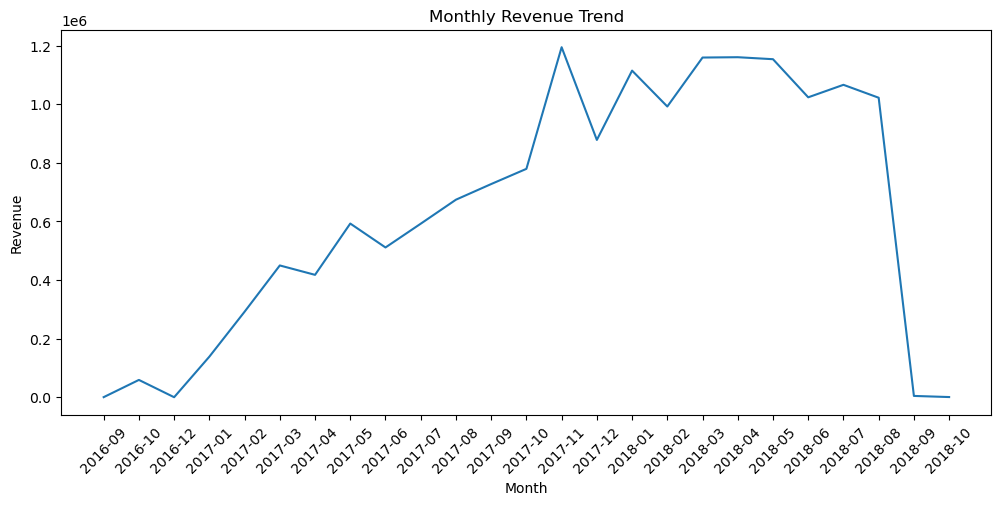

In [40]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_revenue,
    x='month',
    y='revenue'
)

plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

### Insight

This analysis identifies seasonal sales patterns and revenue growth trends over time.

### Top Product Categories by Revenue

In [41]:
query = """
SELECT
    pr.product_category_name,
    ROUND(SUM(p.payment_value), 2) AS revenue
FROM olist_products_dataset pr
JOIN olist_order_items_dataset oi
ON pr.product_id = oi.product_id
JOIN olist_order_payments_dataset p
ON oi.order_id = p.order_id
GROUP BY 1
ORDER BY revenue DESC
LIMIT 10;
"""
top_categories = pd.read_sql(query, conn)

top_categories

,product_category_name,revenue
0,cama_mesa_banho,1712553.67
1,beleza_saude,1657373.12
2,informatica_acessorios,1585330.45
3,moveis_decoracao,1430176.39
4,relogios_presentes,1429216.68
5,esporte_lazer,1392127.56
6,utilidades_domesticas,1094758.13
7,automotivo,852294.33
8,ferramentas_jardim,838280.75
9,cool_stuff,779698.00


### Insight

This query identifies the highest-performing product categories.

### Product Category Visualization

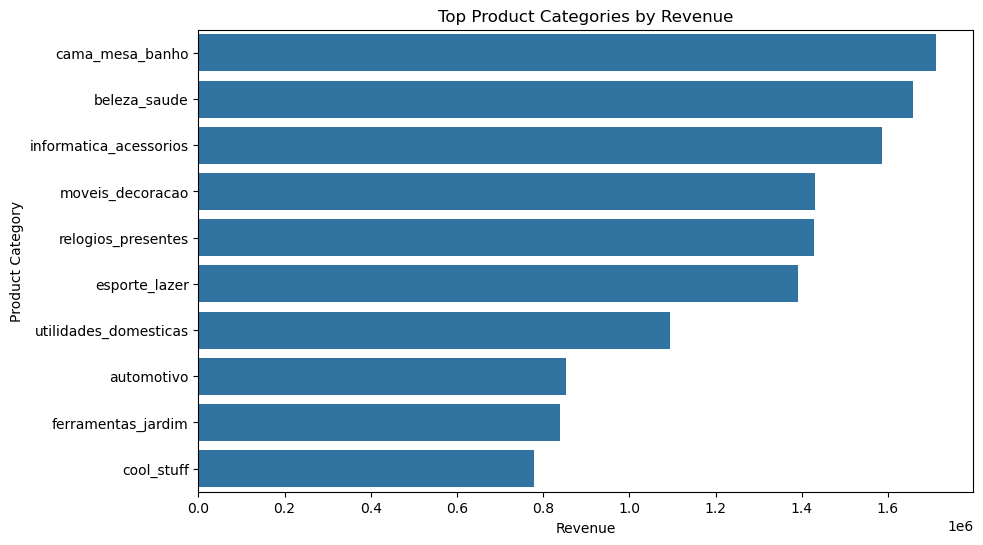

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_categories,
    x='revenue',
    y='product_category_name'
)

plt.title('Top Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')

plt.show()

### Insight

Certain product categories contribute significantly more revenue than others.

### Top Customers by Spending

In [43]:
query="""
SELECT
    c.customer_unique_id,
    ROUND(SUM(p.payment_value), 2) AS total_spent
FROM olist_customers_dataset c
JOIN olist_orders_dataset o
ON c.customer_id = o.customer_id
JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id
GROUP BY 1
ORDER BY total_spent DESC
LIMIT 10;
"""
top_customers = pd.read_sql(query, conn)

top_customers

,customer_unique_id,total_spent
0,0a0a92112bd4c708ca5fde585afaa872,13664.08
1,46450c74a0d8c5ca9395da1daac6c120,9553.02
2,da122df9eeddfedc1dc1f5349a1a690c,7571.63
3,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
4,dc4802a71eae9be1dd28f5d788ceb526,6929.31
5,459bef486812aa25204be022145caa62,6922.21
6,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
7,4007669dec559734d6f53e029e360987,6081.54
8,5d0a2980b292d049061542014e8960bf,4809.44
9,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34


### Insight

This analysis identifies high-value customers for retention strategies.

### Repeat Customer Analysis

In [44]:
query = """
SELECT
    c.customer_unique_id,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM olist_customers_dataset c
JOIN olist_orders_dataset o
ON c.customer_id = o.customer_id
GROUP BY c.customer_unique_id
HAVING COUNT(DISTINCT o.order_id) > 1
ORDER BY total_orders DESC;
"""

repeat_customers = pd.read_sql(query, conn)

repeat_customers.head()

,customer_unique_id,total_orders
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,ca77025e7201e3b30c44b472ff346268,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,1b6c7548a2a1f9037c1fd3ddfed95f33,7


### Insight

Repeat customers are important for customer retention and long-term business growth.

### Average Order Value

In [45]:
query = """
SELECT
    ROUND(
        SUM(payment_value) /
        COUNT(DISTINCT order_id),
        2
    ) AS average_order_value
FROM olist_order_payments_dataset;
"""

aov = pd.read_sql(query, conn)

aov

,average_order_value
0,160.99


### Insight

Average Order Value measures the average revenue generated per order.

### Regional Revenue Analysis

In [46]:
query = """
SELECT
    c.customer_state,
    ROUND(SUM(p.payment_value), 2) AS revenue
FROM olist_customers_dataset c
JOIN olist_orders_dataset o
ON c.customer_id = o.customer_id
JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id
GROUP BY c.customer_state
ORDER BY revenue DESC
LIMIT 10;
"""

state_revenue = pd.read_sql(query, conn)

state_revenue

,customer_state,revenue
0,SP,5998226.96
1,RJ,2144379.69
2,MG,1872257.26
3,RS,890898.54
4,PR,811156.38
5,SC,623086.43
6,BA,616645.82
7,DF,355141.08
8,GO,350092.31
9,ES,325967.55


### Regional Revenue Visualization

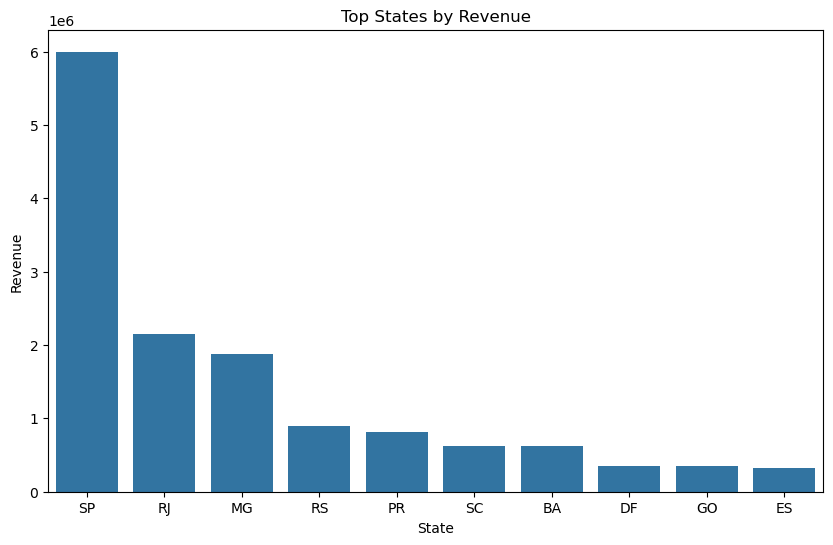

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=state_revenue,
    x='customer_state',
    y='revenue'
)

plt.title('Top States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

### Insight

Some states contribute significantly more revenue than others.

### Customer Spending Analysis Using CTE

In [48]:
query = """
WITH customer_spending AS (
    SELECT
        o.customer_id,
        SUM(p.payment_value) AS total_spent
    FROM olist_orders_dataset o
    JOIN olist_order_payments_dataset p
    ON o.order_id = p.order_id
    GROUP BY o.customer_id
)

SELECT
    customer_id,
    ROUND(total_spent, 2) AS total_spent
FROM customer_spending
WHERE total_spent > 1000
ORDER BY total_spent DESC
LIMIT 10;
"""

high_value_customers = pd.read_sql(query, conn)

high_value_customers

,customer_id,total_spent
0,1617b1357756262bfa56ab541c47bc16,13664.08
1,ec5b2ba62e574342386871631fafd3fc,7274.88
2,c6e2731c5b391845f6800c97401a43a9,6929.31
3,f48d464a0baaea338cb25f816991ab1f,6922.21
4,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66
5,05455dfa7cd02f13d132aa7a6a9729c6,6081.54
6,df55c14d1476a9a3467f131269c2477f,4950.34
7,e0a2412720e9ea4f26c1ac985f6a7358,4809.44
8,24bbf5fd2f2e1b359ee7de94defc4a15,4764.34
9,3d979689f636322c62418b6346b1c6d2,4681.78


### Insight

CTEs help organize complex SQL queries into readable and reusable sections.

### Monthly Revenue Analysis Using CTE

In [49]:
query = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS month,
        SUM(p.payment_value) AS revenue
    FROM olist_orders_dataset o
    JOIN olist_order_payments_dataset p
    ON o.order_id = p.order_id
    GROUP BY month
)

SELECT
    month,
    ROUND(revenue, 2) AS revenue
FROM monthly_sales
ORDER BY month;
"""
monthly_sales_cte = pd.read_sql(query, conn)

monthly_sales_cte.head()

,month,revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01


### Insight

CTEs improve readability and simplify multi-step analytical queries.

### Customer Segmentation Using CASE WHEN

In [50]:
query = """
SELECT
    customer_id,
    total_spent,
    CASE
        WHEN total_spent >= 1000 THEN 'High Value'
        WHEN total_spent >= 500 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS customer_segment
FROM (
    SELECT
        o.customer_id,
        SUM(p.payment_value) AS total_spent
    FROM olist_orders_dataset o
    JOIN olist_order_payments_dataset p
    ON o.order_id = p.order_id
       GROUP BY o.customer_id
);
"""

customer_segments = pd.read_sql(query, conn)

customer_segments.head()

,customer_id,total_spent,customer_segment
0,00012a2ce6f8dcda20d059ce98491703,114.74,Low Value
1,000161a058600d5901f007fab4c27140,67.41,Low Value
2,0001fd6190edaaf884bcaf3d49edf079,195.42,Low Value
3,0002414f95344307404f0ace7a26f1d5,179.35,Low Value
4,000379cdec625522490c315e70c7a9fb,107.01,Low Value


### Insight

Customer segmentation helps identify high-value customers for retention strategies.

### Seller Performance Analysis

In [51]:
query = """
SELECT
    seller_id,
    COUNT(order_id) AS total_orders,
    ROUND(SUM(price), 2) AS total_sales
FROM olist_order_items_dataset
GROUP BY seller_id
ORDER BY total_sales DESC
LIMIT 10;
"""

seller_performance = pd.read_sql(query, conn)

seller_performance

,seller_id,total_orders,total_sales
0,4869f7a5dfa277a7dca6462dcf3b52b2,1156,229472.63
1,53243585a1d6dc2643021fd1853d8905,410,222776.05
2,4a3ca9315b744ce9f8e9374361493884,1987,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,586,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,1364,187923.89
5,7e93a43ef30c4f03f38b393420bc753a,340,176431.87
6,da8622b14eb17ae2831f4ac5b9dab84a,1551,160236.57
7,7a67c85e85bb2ce8582c35f2203ad736,1171,141745.53
8,1025f0e2d44d7041d6cf58b6550e0bfa,1428,138968.55
9,955fee9216a65b617aa5c0531780ce60,1499,135171.70


### Insight

Top sellers contribute disproportionately to marketplace revenue.

### Revenue Running Total Using Window Functions

In [52]:
query = """
SELECT
    month,
    revenue,
    SUM(revenue) OVER (
        ORDER BY month
    ) AS cumulative_revenue
FROM (
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS month,
        ROUND(SUM(p.payment_value), 2) AS revenue
    FROM olist_orders_dataset o
    JOIN olist_order_payments_dataset p
    ON o.order_id = p.order_id
    GROUP BY month
);
"""

In [53]:
running_revenue = pd.read_sql(query, conn)

running_revenue.head()

,month,revenue,cumulative_revenue
0,2016-09,252.24,252.24
1,2016-10,59090.48,59342.72
2,2016-12,19.62,59362.34
3,2017-01,138488.04,197850.38
4,2017-02,291908.01,489758.39


### Insight

Window functions help analyze cumulative business growth over time.

### Order Status Analysis

In [54]:
query = """
SELECT
    order_status,
    COUNT(*) AS total_orders
FROM olist_orders_dataset
GROUP BY order_status
ORDER BY total_orders DESC;
"""

order_status = pd.read_sql(query, conn)

order_status

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


### Order Status Visualization

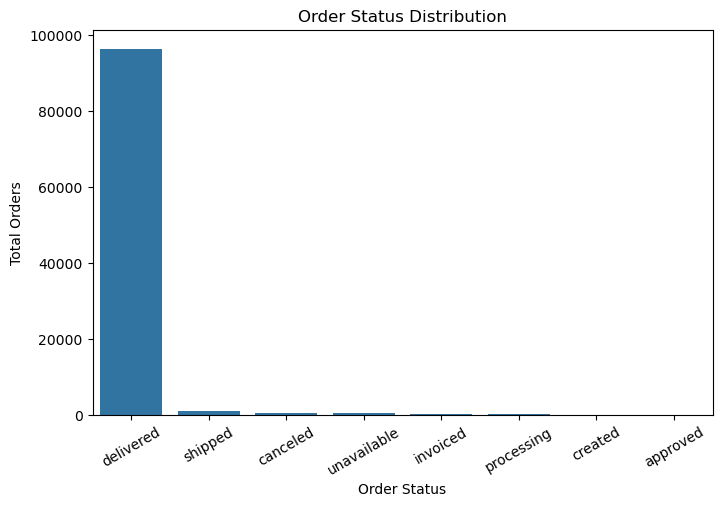

In [55]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=order_status,
    x='order_status',
    y='total_orders'
)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Total Orders')

plt.xticks(rotation=30)

plt.show()

### Insight

Most orders are successfully delivered, while some are canceled or unavailable.

### Delivery Performance Analysis

In [56]:
query = """
SELECT
    AVG(
        julianday(order_delivered_customer_date) -
        julianday(order_purchase_timestamp)
    ) AS avg_delivery_days
FROM olist_orders_dataset
WHERE order_status = 'delivered';
"""

delivery = pd.read_sql(query, conn)

delivery

,avg_delivery_days
0,12.558217


### Insight

Average delivery time was approximately 12.6 days, indicating the overall delivery efficiency of the marketplace.

## Key Business Insights

- Revenue demonstrated strong growth throughout 2017 with noticeable seasonal purchasing trends.

- Bed, Bath & Table, Health & Beauty, and Computer Accessories were the top-performing product categories by revenue.

- Most customers placed only one order, highlighting opportunities to improve customer retention and loyalty programs.

- Repeat customers contributed significantly to long-term revenue generation.

- São Paulo (SP) generated the highest marketplace revenue among all states.

- Average order value was approximately 161 BRL per transaction.

- Average delivery time for completed orders was approximately 12.6 days.

- A relatively small group of sellers contributed disproportionately to total marketplace sales, indicating seller concentration.

## Business Recommendations

- Improve customer retention through loyalty and repeat-purchase campaigns
- Focus marketing efforts on high-performing product categories
- Optimize delivery operations to reduce shipping times
- Strengthen partnerships with top-performing sellers

## Tools & Technologies

- Python
- Pandas
- SQLite
- SQL
- Matplotlib
- Seaborn
- Power BI
- Jupyter Notebook

## Power BI Dashboard

An interactive Power BI dashboard was developed to visualize:
- Revenue trends
- Customer behavior
- Product category performance
- Regional sales analysis
- Order status distribution
- Key business KPIs

The dashboard file and screenshots are included in the project repository.